System cores detected : 2
Will test T=1 to T=4 threads
Matrix size           : 2000 x 2000
Number of matrices    : 300

Running with T=1 thread(s)...
  T= 1 → 1.8804 min  | CPU avg per core: [99.6, 99.6]

Running with T=2 thread(s)...
  T= 2 → 1.8144 min  | CPU avg per core: [100.0, 100.0]

Running with T=3 thread(s)...
  T= 3 → 1.7768 min  | CPU avg per core: [99.6, 99.6]

Running with T=4 thread(s)...
  T= 4 → 1.7456 min  | CPU avg per core: [99.8, 99.9]


RESULTS TABLE
Threads           T=1     T=2     T=3     T=4     
Time Taken (min)  1.8804  1.8144  1.7768  1.7456  
Time Taken (sec)  112.8   108.9   106.6   104.7   


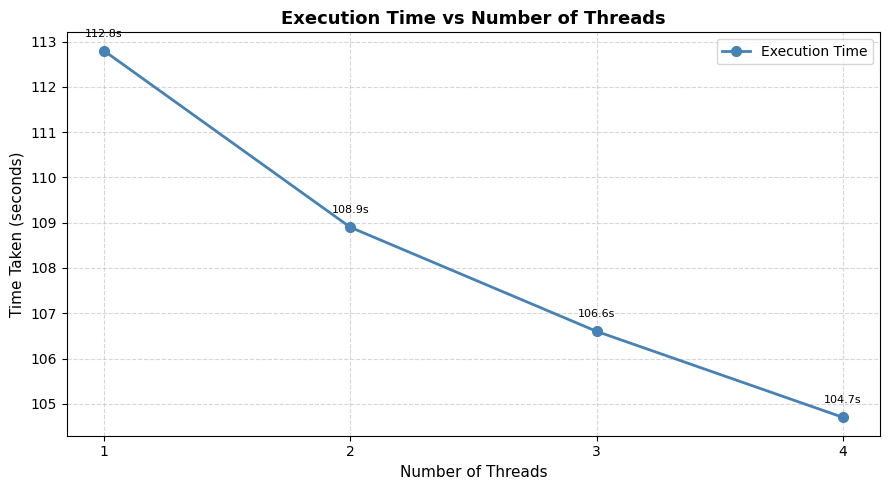

Graph saved → execution_time_graph.png


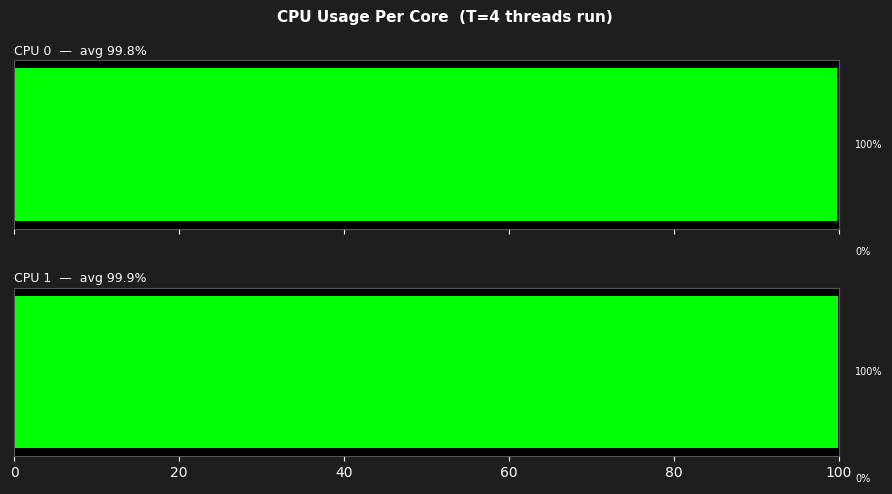

CPU graph saved → cpu_usage_per_core.png

Fastest run : T=4  (1.7456 min)
Slowest run : T=1  (1.8804 min)
Speedup (T1→T4) : 1.08x


In [1]:
import numpy as np
import multiprocessing
import time
import matplotlib.pyplot as plt
import psutil
import threading
from concurrent.futures import ProcessPoolExecutor
MATRIX_SIZE  = 2000
NUM_MATRICES = 300
NUM_CORES    = multiprocessing.cpu_count()
MAX_THREADS  = 2 * NUM_CORES

print(f"System cores detected : {NUM_CORES}")
print(f"Will test T=1 to T={MAX_THREADS} threads")
print(f"Matrix size           : {MATRIX_SIZE} x {MATRIX_SIZE}")
print(f"Number of matrices    : {NUM_MATRICES}")
print("=" * 55)

CONSTANT_MATRIX = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float32)

def multiply_one(task_id):
    random_matrix = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float32)
    result = random_matrix @ CONSTANT_MATRIX
    return result.shape

class CPUMonitor:
    def __init__(self):
        self.monitoring  = False
        self.cpu_samples = []
        self._thread     = None

    def start(self):
        self.monitoring  = True
        self.cpu_samples = []
        self._thread = threading.Thread(target=self._sample, daemon=True)
        self._thread.start()

    def stop(self):
        self.monitoring = False
        if self._thread:
            self._thread.join(timeout=2)

    def _sample(self):
        while self.monitoring:
            self.cpu_samples.append(psutil.cpu_percent(interval=0.5, percpu=True))

    def average_per_core(self):
        if not self.cpu_samples:
            return []
        num_cores = len(self.cpu_samples[0])
        return [
            round(sum(s[c] for s in self.cpu_samples) / len(self.cpu_samples), 1)
            for c in range(num_cores)
        ]

def run_experiment(num_threads):
    monitor = CPUMonitor()
    monitor.start()

    start_time = time.time()
    with ProcessPoolExecutor(max_workers=num_threads) as executor:
        results = list(executor.map(multiply_one, range(NUM_MATRICES), chunksize=10))
    elapsed_seconds = time.time() - start_time

    monitor.stop()

    elapsed_minutes = elapsed_seconds / 60.0
    avg_cpu = monitor.average_per_core()

    print(f"  T={num_threads:2d} → {elapsed_minutes:.4f} min  "
          f"| CPU avg per core: {avg_cpu}")

    return elapsed_minutes, avg_cpu

if __name__ == "__main__":

    thread_counts = list(range(1, MAX_THREADS + 1))
    times_minutes = []
    cpu_per_run   = []

    for t in thread_counts:
        print(f"\nRunning with T={t} thread(s)...")
        elapsed, avg_cpu = run_experiment(t)
        times_minutes.append(round(elapsed, 4))
        cpu_per_run.append(avg_cpu)

    times_seconds = [round(m * 60, 1) for m in times_minutes]

    print("\n")
    print("=" * 70)
    print("RESULTS TABLE")
    print("=" * 70)
    header = f"{'Threads':<18}" + "".join(f"T={t:<6}" for t in thread_counts)
    row_m  = f"{'Time Taken (min)':<18}" + "".join(f"{v:<8}" for v in times_minutes)
    row_s  = f"{'Time Taken (sec)':<18}" + "".join(f"{v:<8}" for v in times_seconds)
    print(header)
    print(row_m)
    print(row_s)
    print("=" * 70)

    fig1, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thread_counts, times_seconds, marker='o', color='steelblue',
            linewidth=2, markersize=7, label='Execution Time')
    for x, y in zip(thread_counts, times_seconds):
        ax.annotate(f"{y}s", (x, y), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=8)
    ax.set_title("Execution Time vs Number of Threads", fontsize=13, fontweight='bold')
    ax.set_xlabel("Number of Threads", fontsize=11)
    ax.set_ylabel("Time Taken (seconds)", fontsize=11)
    ax.set_xticks(thread_counts)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig("execution_time_graph.png", dpi=150)
    plt.show()
    print("Graph saved → execution_time_graph.png")

    best_cpu_data      = cpu_per_run[-1]
    num_cores_detected = len(best_cpu_data)

    fig2, axes = plt.subplots(num_cores_detected, 1,
                              figsize=(9, 2.5 * num_cores_detected),
                              sharex=True)
    if num_cores_detected == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        usage = best_cpu_data[i] if i < len(best_cpu_data) else 0
        ax.barh(0, usage, color='lime', height=0.5)
        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.set_facecolor('black')
        fig2.patch.set_facecolor('#1e1e1e')
        ax.tick_params(colors='white')
        ax.spines[:].set_color('#555')
        ax.set_title(f"CPU {i}  —  avg {usage}%", color='white',
                     fontsize=9, loc='left', pad=4)
        ax.text(102, 0,     "100%", va='center', fontsize=7, color='white')
        ax.text(102, -0.35, "0%",   va='center', fontsize=7, color='white')

    fig2.suptitle(f"CPU Usage Per Core  (T={MAX_THREADS} threads run)",
                  color='white', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig("cpu_usage_per_core.png", dpi=150, facecolor='#1e1e1e')
    plt.show()
    print("CPU graph saved → cpu_usage_per_core.png")

    best_t  = thread_counts[times_minutes.index(min(times_minutes))]
    worst_t = thread_counts[times_minutes.index(max(times_minutes))]
    print(f"\nFastest run : T={best_t}  ({min(times_minutes):.4f} min)")
    print(f"Slowest run : T={worst_t}  ({max(times_minutes):.4f} min)")
    print(f"Speedup (T1→T{best_t}) : {times_minutes[0]/min(times_minutes):.2f}x")